# Gold Price Forecating using LSTM(Long Short Term Memory)

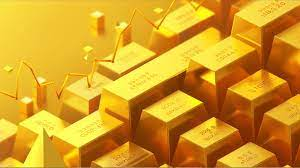

### Importing the Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore')

### Loading the Dataset

In [2]:
gold_df = pd.read_csv(r"E:\class\Capstone Project II\Gold price prediction\gld_price_data.csv")

### Dataset Overview

In [3]:
gold_df

,Date,Price,Open,High,Low,Vol.,Change %
0,12/30/2022,"1,826.20","1,821.80","1,832.40","1,819.80",107.50K,0.01%
1,12/29/2022,"1,826.00","1,812.30","1,827.30","1,811.20",105.99K,0.56%
2,12/28/2022,"1,815.80","1,822.40","1,822.80","1,804.20",118.08K,-0.40%
3,12/27/2022,"1,823.10","1,808.20","1,841.90","1,808.00",159.62K,0.74%
4,12/26/2022,"1,809.70","1,805.80","1,811.95","1,805.55",NaN,0.30%
...,...,...,...,...,...,...,...
2578,01/08/2013,"1,663.20","1,651.50","1,662.60","1,648.80",0.13K,0.97%
2579,01/07/2013,"1,647.20","1,657.30","1,663.80","1,645.30",0.09K,-0.16%
2580,01/04/2013,"1,649.90","1,664.40","1,664.40","1,630.00",0.31K,-1.53%
2581,01/03/2013,"1,675.60","1,688.00","1,689.30","1,664.30",0.19K,-0.85%


##### As we can see, 
- this dataset contains gold price data from year 2013 to 2022.
- daily gold price information including daily Open, High and Low prices and the 
  final price of each day (Price) along with the volume of transactions and price changes in each day.
- Shape of the dataset is 2583 rows × 7 columns.

In [4]:
gold_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2583 entries, 0 to 2582
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Date      2583 non-null   object
 1   Price     2583 non-null   object
 2   Open      2583 non-null   object
 3   High      2583 non-null   object
 4   Low       2583 non-null   object
 5   Vol.      2578 non-null   object
 6   Change %  2583 non-null   object
dtypes: object(7)
memory usage: 141.4+ KB


##### Insights
- All features are stored as object datatype.
- There are some missing values in Vol feature

### Data Preprocessing

In [12]:
# Converting Date feature to datetime
gold_df['Date'] = pd.to_datetime(gold_df['Date'])

In [13]:
gold_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2583 entries, 0 to 2582
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      2583 non-null   datetime64[ns]
 1   Price     2583 non-null   object        
 2   Open      2583 non-null   object        
 3   High      2583 non-null   object        
 4   Low       2583 non-null   object        
 5   Vol.      2578 non-null   object        
 6   Change %  2583 non-null   object        
dtypes: datetime64[ns](1), object(6)
memory usage: 141.4+ KB


In [14]:
gold_df = gold_df.sort_values('Date')   # sorting dataset according to date values in ascending order
gold_df = gold_df.reset_index(drop = True) # resetting index after sorting 

In [15]:
gold_df

,Date,Price,Open,High,Low,Vol.,Change %
0,2013-01-02,1689.90,1675.80,1695.00,1672.10,0.06K,0.78%
1,2013-01-03,1675.60,1688.00,1689.30,1664.30,0.19K,-0.85%
2,2013-01-04,1649.90,1664.40,1664.40,1630.00,0.31K,-1.53%
3,2013-01-07,1647.20,1657.30,1663.80,1645.30,0.09K,-0.16%
4,2013-01-08,1663.20,1651.50,1662.60,1648.80,0.13K,0.97%
...,...,...,...,...,...,...,...
2578,2022-12-26,1809.70,1805.80,1811.95,1805.55,NaN,0.30%
2579,2022-12-27,1823.10,1808.20,1841.90,1808.00,159.62K,0.74%
2580,2022-12-28,1815.80,1822.40,1822.80,1804.20,118.08K,-0.40%
2581,2022-12-29,1826.00,1812.30,1827.30,1811.20,105.99K,0.56%


In [16]:
# The " , " sign is redundant in the dataset. need to remove it from the entire dataset.

In [17]:
gold_df['Price'] = gold_df['Price'].str.replace(',','')
gold_df['Open'] = gold_df['Open'].str.replace(',','')
gold_df['High'] = gold_df['High'].str.replace(',','')
gold_df['Low'] = gold_df['Low'].str.replace(',','')

In [18]:
gold_df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,2013-01-02,1689.90,1675.80,1695.00,1672.10,0.06K,0.78%
1,2013-01-03,1675.60,1688.00,1689.30,1664.30,0.19K,-0.85%
2,2013-01-04,1649.90,1664.40,1664.40,1630.00,0.31K,-1.53%
3,2013-01-07,1647.20,1657.30,1663.80,1645.30,0.09K,-0.16%
4,2013-01-08,1663.20,1651.50,1662.60,1648.80,0.13K,0.97%


In [19]:
 # Change the data type of the numerical variables to float

In [20]:
conver_dict = {'Price': float, 'Open':float, 'High':float, 'Low':float}

gold_df = gold_df.astype(conver_dict)

In [21]:
gold_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2583 entries, 0 to 2582
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      2583 non-null   datetime64[ns]
 1   Price     2583 non-null   float64       
 2   Open      2583 non-null   float64       
 3   High      2583 non-null   float64       
 4   Low       2583 non-null   float64       
 5   Vol.      2578 non-null   object        
 6   Change %  2583 non-null   object        
dtypes: datetime64[ns](1), float64(4), object(2)
memory usage: 141.4+ KB


##### Understanding Volume Feature-
- Here Vol feature indicates volume of transactions of gold for that particular day.
- Transaction volume refers to the total number of individual orders or purchases processed through over a specific period of time.

In [22]:
gold_df['Vol.'] = gold_df['Vol.'].str.replace('K','')
gold_df['Vol.'] = gold_df['Vol.'].astype(float)
gold_df['Vol.'] = gold_df['Vol.']*1000

In [23]:
gold_df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,2013-01-02,1689.9,1675.8,1695.0,1672.1,60.0,0.78%
1,2013-01-03,1675.6,1688.0,1689.3,1664.3,190.0,-0.85%
2,2013-01-04,1649.9,1664.4,1664.4,1630.0,310.0,-1.53%
3,2013-01-07,1647.2,1657.3,1663.8,1645.3,90.0,-0.16%
4,2013-01-08,1663.2,1651.5,1662.6,1648.8,130.0,0.97%


##### Understanding the Change % feature

- Daily gold price changes are calculated by taking the difference between the current day’s price 
  and the previous day’s closing price.
- Change in percentage is ((Current day price - Previous day price)/previous day price)*100

In [24]:
gold_df['Change %'] = gold_df['Change %'].str.replace("%", '')
gold_df['Change %'] = gold_df['Change %'].astype(float)

In [25]:
gold_df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,2013-01-02,1689.9,1675.8,1695.0,1672.1,60.0,0.78
1,2013-01-03,1675.6,1688.0,1689.3,1664.3,190.0,-0.85
2,2013-01-04,1649.9,1664.4,1664.4,1630.0,310.0,-1.53
3,2013-01-07,1647.2,1657.3,1663.8,1645.3,90.0,-0.16
4,2013-01-08,1663.2,1651.5,1662.6,1648.8,130.0,0.97


In [26]:
gold_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2583 entries, 0 to 2582
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      2583 non-null   datetime64[ns]
 1   Price     2583 non-null   float64       
 2   Open      2583 non-null   float64       
 3   High      2583 non-null   float64       
 4   Low       2583 non-null   float64       
 5   Vol.      2578 non-null   float64       
 6   Change %  2583 non-null   float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 141.4 KB


In [27]:
# Checking null values
gold_df.isnull().sum()

Date        0
Price       0
Open        0
High        0
Low         0
Vol.        5
Change %    0
dtype: int64

In [28]:
gold_df = gold_df.dropna()

In [29]:
gold_df.shape

(2578, 7)

In [30]:
# seting index as Date feature
gold_df.set_index('Date', inplace = True)

In [31]:
gold_df.head()

,Price,Open,High,Low,Vol.,Change %
Date,,,,,,
2013-01-02,1689.9,1675.8,1695.0,1672.1,60.0,0.78
2013-01-03,1675.6,1688.0,1689.3,1664.3,190.0,-0.85
2013-01-04,1649.9,1664.4,1664.4,1630.0,310.0,-1.53
2013-01-07,1647.2,1657.3,1663.8,1645.3,90.0,-0.16
2013-01-08,1663.2,1651.5,1662.6,1648.8,130.0,0.97


### EDA - Visualizing the Gold Prices

In [32]:
# set the global parameters of visualization

sns.set(style = 'whitegrid', palette = 'muted', font_scale = 1.2)
plt.rcParams['figure.figsize']=(12,6)

##### Visualization of Gold price over time(2013-2022)

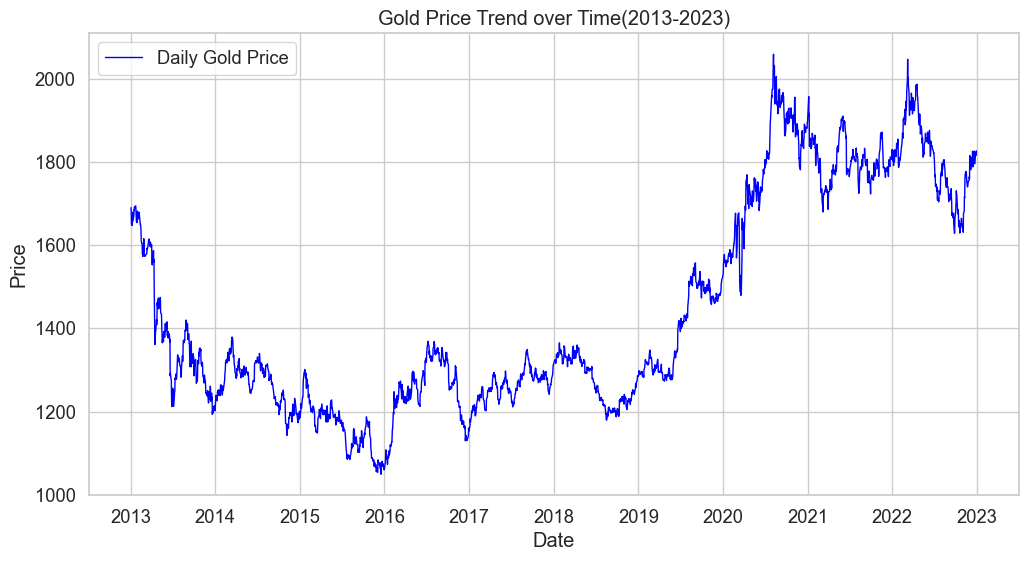

In [33]:
plt.figure(figsize = (12,6))
plt.plot(gold_df.index, gold_df['Price'], label = 'Daily Gold Price', linewidth = 1, color = 'blue')
plt.title("Gold Price Trend over Time(2013-2023)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

- From the above visualization, we can see there is lot of randomness present in the data, because, here data volume is in high quantity.
- To imporve the readability and understand the overall trends in data, we will use "Moving Average Method" to visualize this data.
- The moving average method is primarily used in data visualization to smooth out short-term fluctuations (noise) and 
  highlight long-term trends or cycles in time-series data.

##### Visualization of Gold price over time (2013-2023) Using "Moving Average Method"

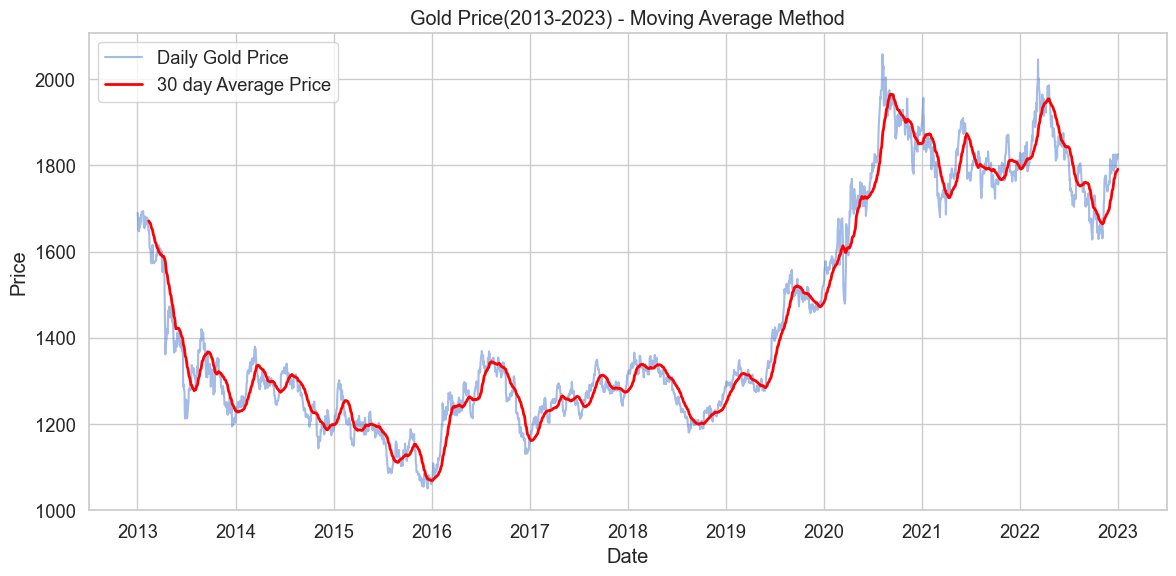

In [35]:
rolling_mean = gold_df['Price'].rolling(window=30).mean()
plt.figure(figsize = (12,6))
plt.plot(gold_df.index, gold_df['Price'], label = "Daily Gold Price", alpha = 0.5)
plt.plot(rolling_mean, label = '30 day Average Price', color = 'red', linewidth = 2)
plt.title("Gold Price(2013-2023) - Moving Average Method")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

From this visualization - 
- from 2013 to 2016 we can see that gold price was continuosly falling down with minor upword trends.
- Again from 2016 to untill 2019 we can able to see mix trend.
- But after 2019 gold prices has shown strong long term upward trend.
- In the last few months of 2023, the gold market has experienced a mild upward trend

##### Distribution of Gold price - Histogram

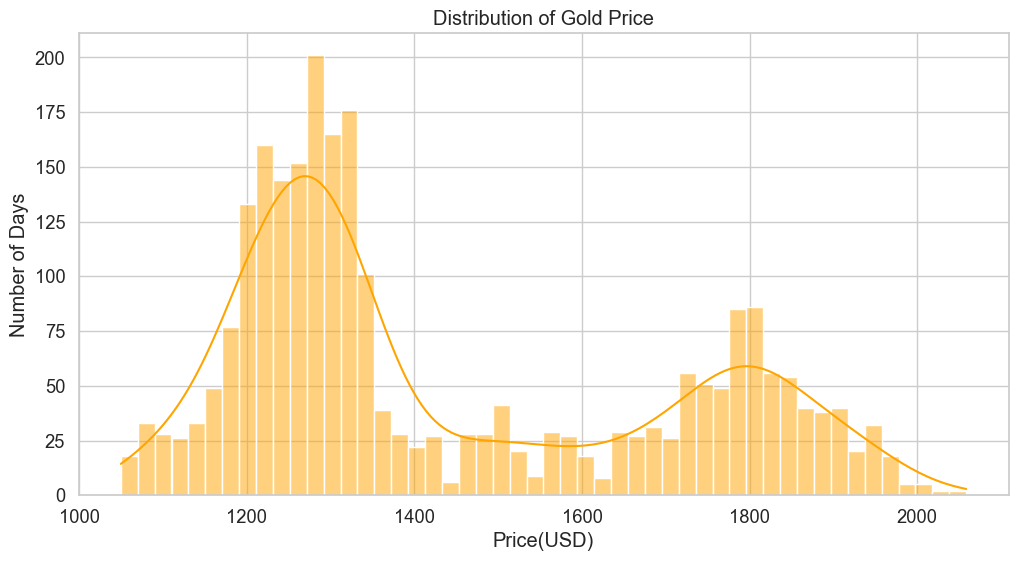

In [36]:
plt.figure(figsize=(12,6))
sns.histplot(gold_df['Price'], bins = 50, kde = True, color = 'orange') 
plt.title("Distribution of Gold Price")
plt.xlabel("Price(USD)")
plt.ylabel("Number of Days")
plt.grid(True)
plt.show()

From this plot-
- Gold price stayed between 1200 to 1400 for longest time.
- Then second long stay is around 1800.

##### ACF (Auto-Correlation)

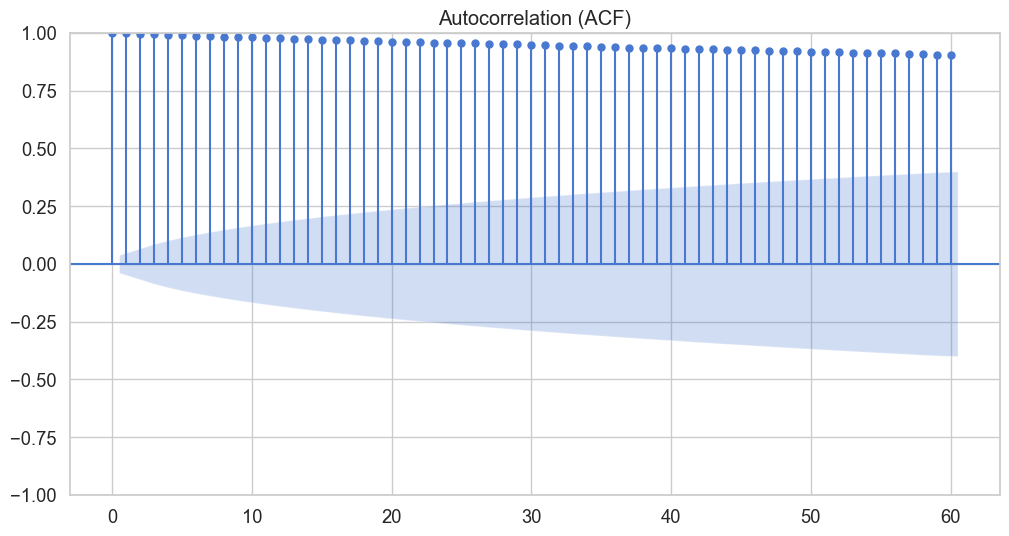

In [37]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(gold_df['Price'], lags = 60) # Plot the Autocorrelation Function (ACF)
#lag tells you how far back in time you are looking to see if there is a relationship with the current data. 
plt.title("Autocorrelation (ACF)")
plt.show()

Interpretation- 
- Slow Decrease in ACF, Suggests a trend is present, indicating non-stationary data.

##### Seasonal Decomposition

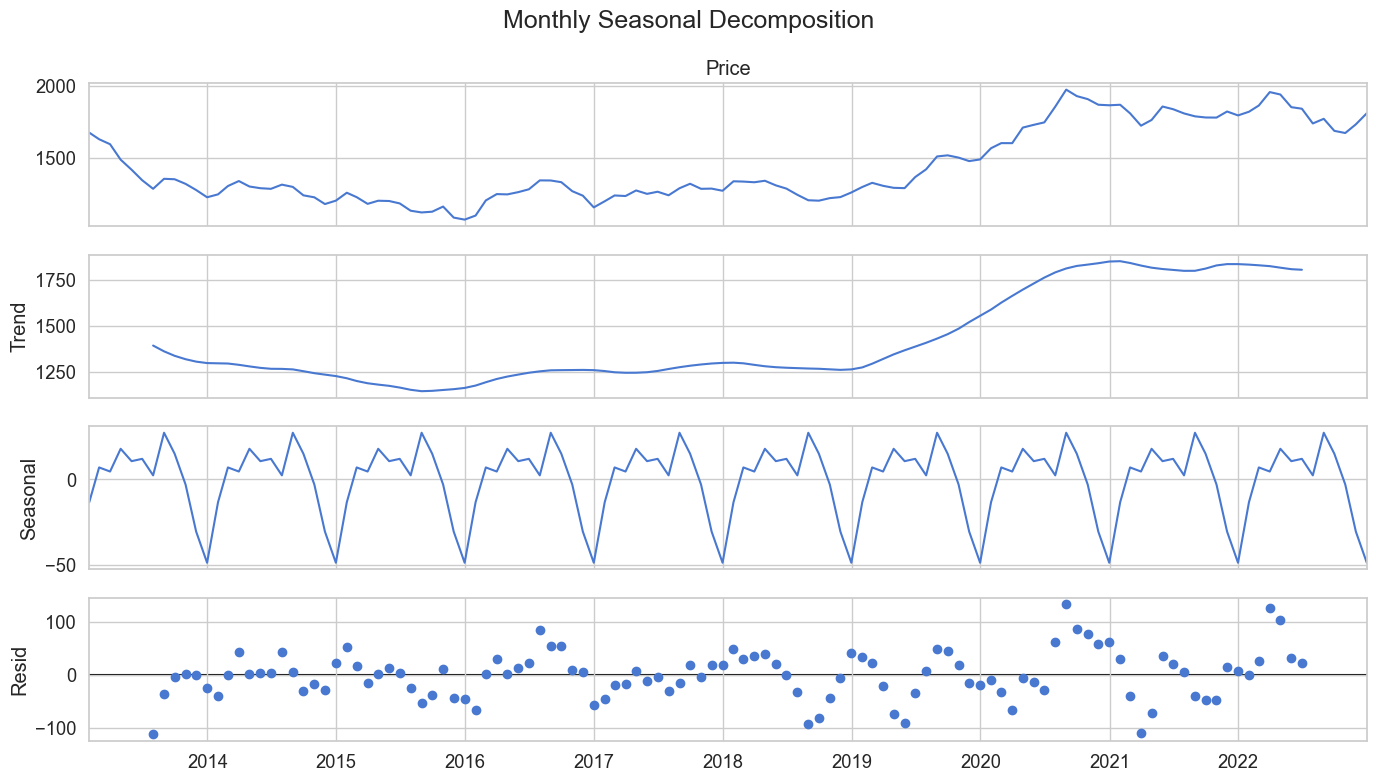

In [38]:
from statsmodels.tsa.seasonal import seasonal_decompose
monthly_df = gold_df['Price'].resample('M').mean()
decompostion = seasonal_decompose(monthly_df)
fig = decompostion.plot()
fig.set_size_inches(14,8)
plt.suptitle("Monthly Seasonal Decomposition", fontsize = 18)
plt.tight_layout()
plt.show()

##### Daily Change% in price (Volatility)

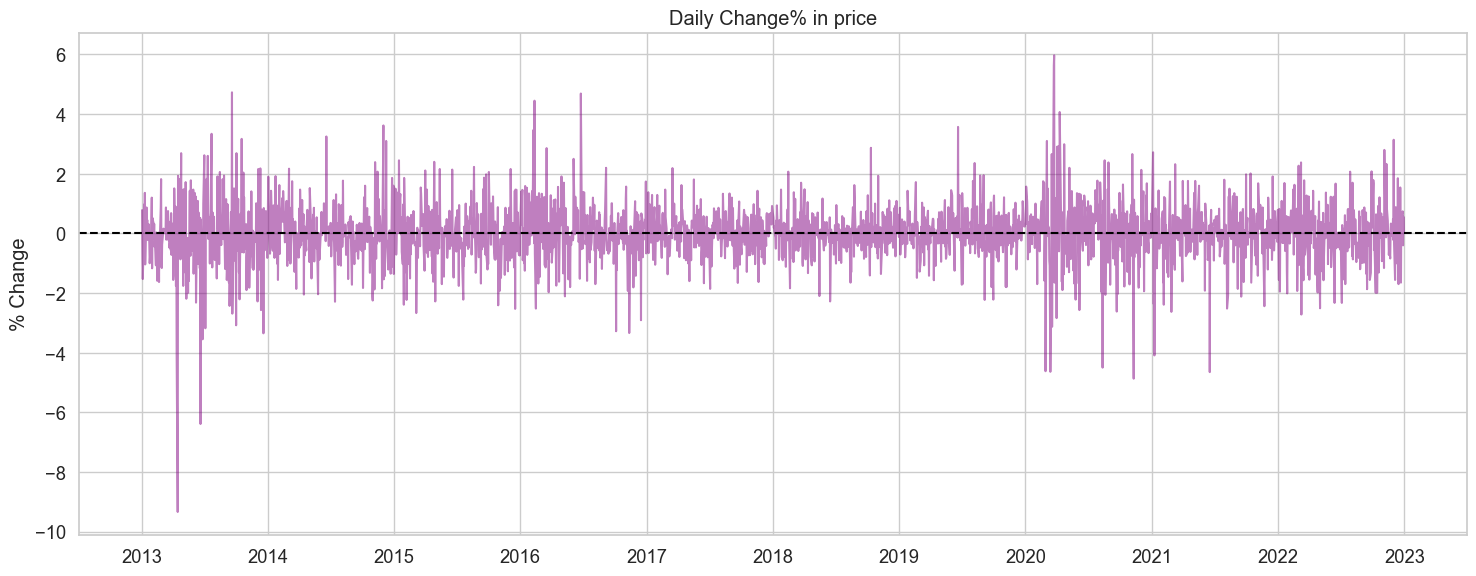

In [39]:
plt.figure(figsize=(15,6))
plt.plot(gold_df.index, gold_df["Change %"], color = "purple", alpha = 0.5)
plt.axhline(0, color = 'black', linestyle = '--')
plt.title("Daily Change% in price")
plt.ylabel("% Change")
plt.tight_layout()
plt.show()

There are few times, where price has changes very abruptly.

##### Boxplot by year

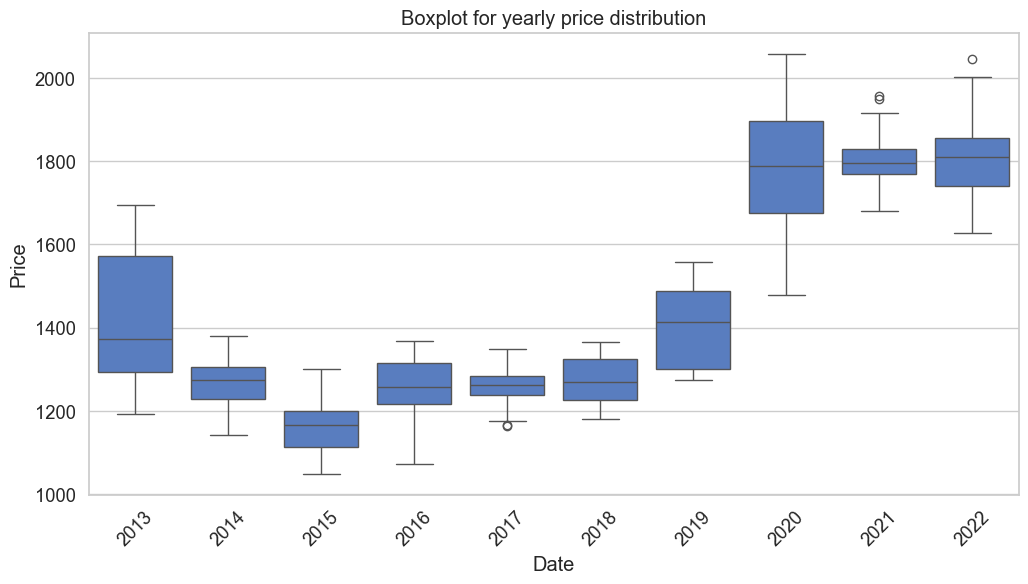

In [40]:
plt.figure(figsize=(12,6))
sns.boxplot(x = gold_df.index.year, y = 'Price', data = gold_df)
plt.title("Boxplot for yearly price distribution")
plt.xticks(rotation=45)
plt.show()

### Data Preparation 

In [42]:
from sklearn.preprocessing import MinMaxScaler

window_size = 60 # it defines the amount of historical, sequential data the model uses to make future predictions
data = gold_df[["Price"]].copy()
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

test_size = gold_df[gold_df.index.year == 2022].shape[0]

train_data = scaled_data[:-test_size]
test_data = scaled_data[-test_size-window_size:]

print("Scaled Data Shape is", scaled_data.shape)
print("Train Data Shape is", train_data.shape)
print("Test Data Shape is", test_data.shape)

Scaled Data Shape is (2578, 1)
Train Data Shape is (2322, 1)
Test Data Shape is (316, 1)


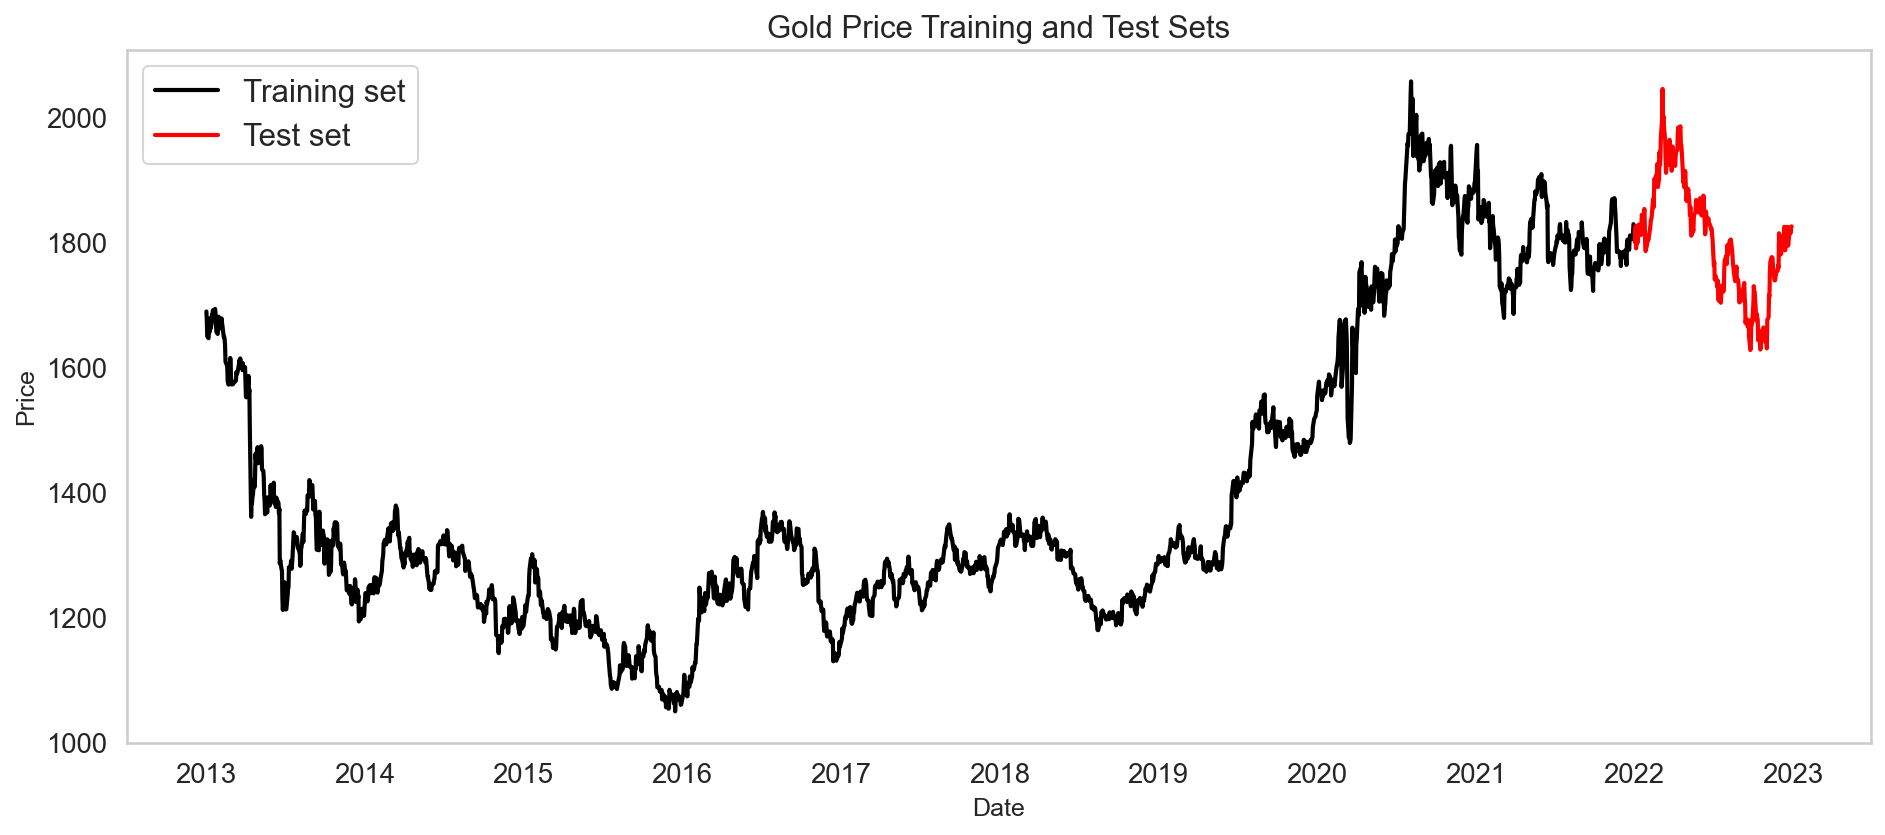

In [44]:
df_reset = gold_df.reset_index()

plt.figure(figsize=(15, 6), dpi=150)
plt.plot(df_reset['Date'][:-test_size], df_reset['Price'][:-test_size], color='black', lw=2)
plt.plot(df_reset['Date'][-test_size:], df_reset['Price'][-test_size:], color='red', lw=2)
plt.title('Gold Price Training and Test Sets', fontsize=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.legend(['Training set', 'Test set'], loc='upper left', prop={'size': 15})
plt.grid(color='white')
plt.show()

### Model Building - LSTM

In [45]:
# preparing sequences for LSTM 

def create_sequence(data, window_size):
    X = []
    y = []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i,0]) # 60 previous value
        y.append(data[i,0])
    return np.array(X), np.array(y)

window_size = 60
X_train, y_train = create_sequence(train_data, window_size)
X_test, y_test = create_sequence(test_data, window_size)

# Converting into 3D for LSTM
X_train = X_train.reshape((X_train.shape[0],X_train.shape[1],1))
X_test = X_test.reshape((X_test.shape[0],X_test.shape[1],1))

In [46]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential()
# Add an LSTM layer with 50 units, input shape, and return sequences if stacking more LSTM layers
model.add(LSTM(units=50, return_sequences=False, input_shape=(X_train.shape[1], 1)))
# Optional: Add Dropout to prevent overfitting
model.add(Dropout(0.2))
# Add a Dense layer to produce the final output value
model.add(Dense(units=1))

# compile the model
model.compile(optimizer= Adam(learning_rate = 0.001), loss='mean_squared_error')

# History
history = model.fit(
    X_train, y_train,
    epochs = 20,
    batch_size = 32,
    validation_data = (X_test, y_test),
    verbose = 1
)

Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - loss: 0.0133 - val_loss: 0.0013
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0024 - val_loss: 0.0012
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0021 - val_loss: 0.0014
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0020 - val_loss: 0.0021
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0019 - val_loss: 9.9860e-04
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0017 - val_loss: 0.0018
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0018 - val_loss: 9.4773e-04
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.0016 - val_loss: 9.2748e-04
Epoch 9/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0016 - val_loss: 9.9357e-04
Epoch 10/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0015 - val_loss: 8.1498e-04
Epoch 11/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.0014 - val_loss: 7.9764e-04
Epoch 12/20
71/71 ━━━━━━━━━━━━━━━━━━━━

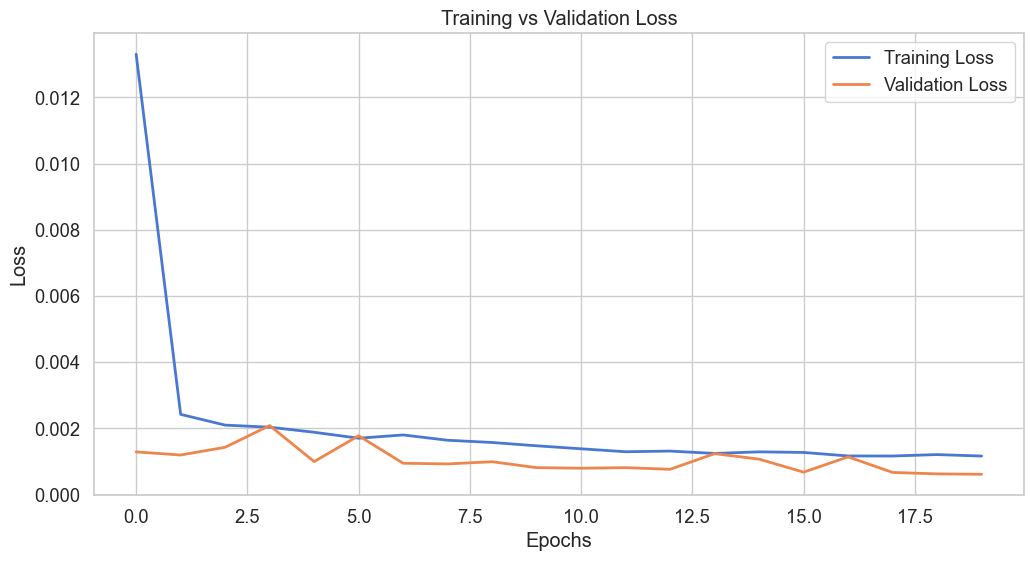

In [47]:
# Plotting loss function

plt.figure(figsize = (12,6))
plt.plot(history.history['loss'], label = "Training Loss", linewidth = 2)
plt.plot(history.history['val_loss'], label = "Validation Loss", linewidth = 2)
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

Here, Training and validation losses are almost close to each other. we can say,No issue of overfitting occurs here.

##### Evaluation on Test data

In [48]:
result = model.evaluate(X_test, y_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 6.1537e-04


In [49]:
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, mean_absolute_error, r2_score

# Prediction
y_pred = model.predict(X_test)

print(f"Test Loss: {result}")

#Calculations
#Compute MAPE
MAPE = mean_absolute_percentage_error(y_test, y_pred)
print(f"MAPE: {MAPE}")

# Compute Accuracy
Accuracy = 1-MAPE
print(f"Accuracy: {Accuracy}")

# Compute RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse}")

# Compute MAE
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE: {mae}")

# Compute R² Score
r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step 
Test Loss: 0.0006153674330562353
MAPE: 0.026457418214550908
Accuracy: 0.9735425817854491
RMSE: 0.024806601836322138
MAE: 0.019503777287605023
R² Score: 0.9250415276314813


In [50]:
y_test_true = scaler.inverse_transform(y_test.reshape(-1,1))
y_test_pred = scaler.inverse_transform(y_pred)                                    

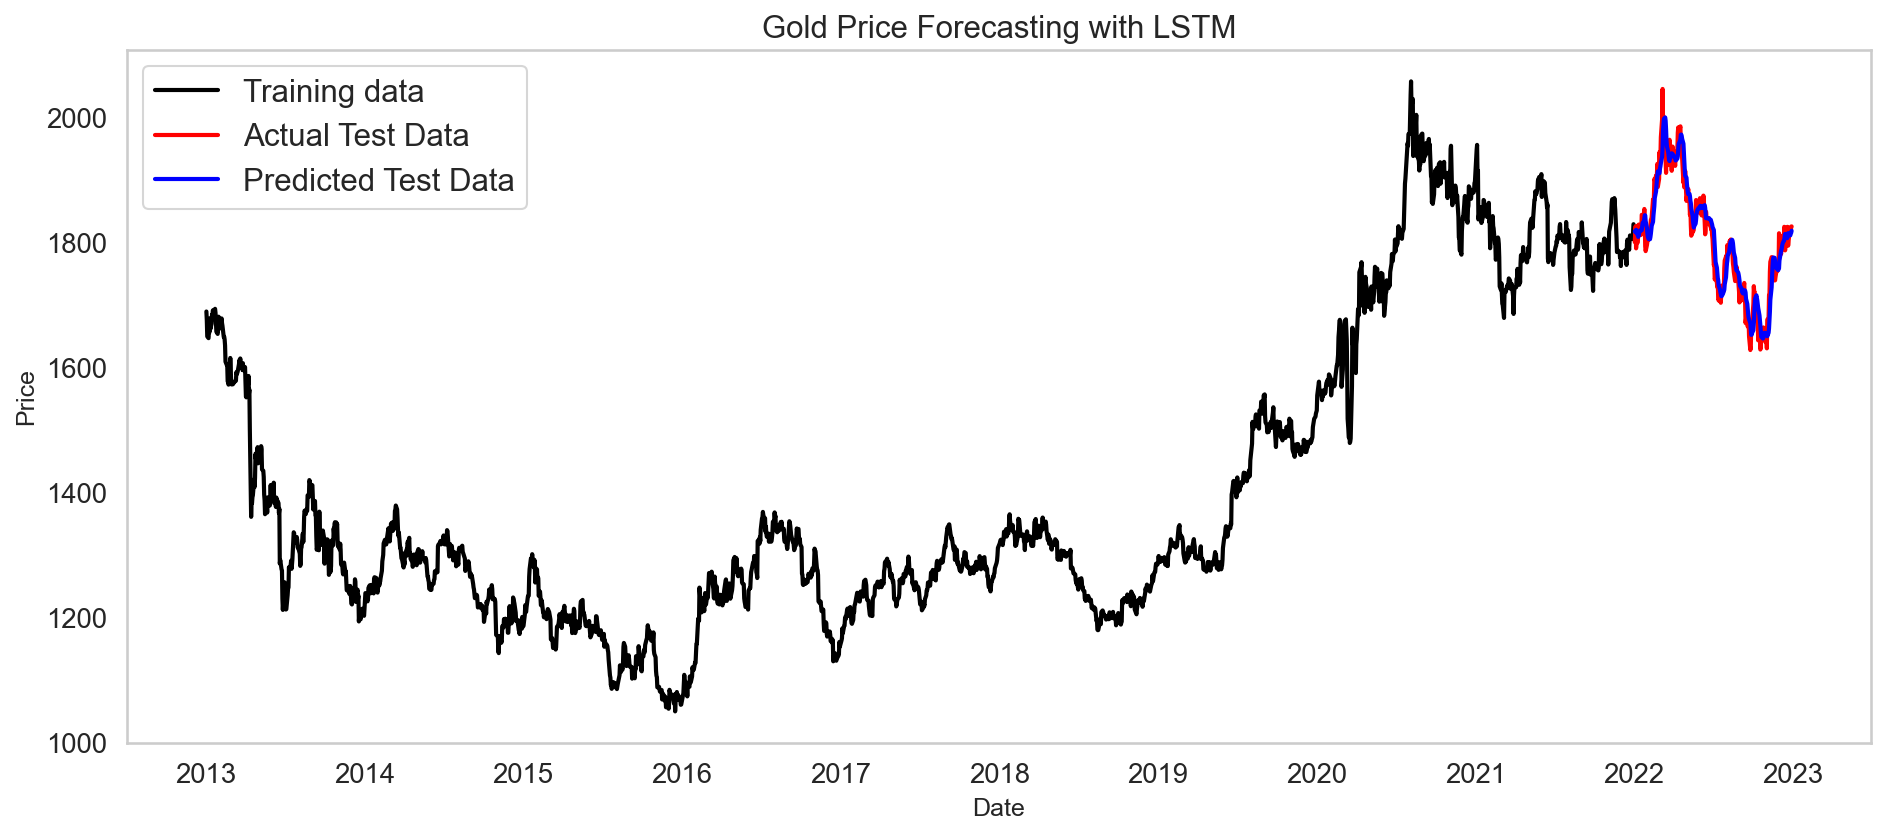

In [51]:
test_dates = gold_df.index[-test_size-window_size:][-len(y_test_true):]
train_dates = gold_df.index[:len(train_data)]

plt.figure(figsize=(15, 6), dpi=150)

plt.plot(train_dates, scaler.inverse_transform(train_data), color = 'black', lw=2, label = 'Training data')
plt.plot(test_dates, y_test_true, color = 'red', lw=2, label = 'Actual Test Data')
plt.plot(test_dates, y_test_pred, color = 'blue', lw=2, label = 'Predicted Test Data')

plt.title('Gold Price Forecasting with LSTM', fontsize=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.legend(loc='upper left', prop={'size': 15})
plt.grid(color='white')
plt.show()

### Future Forecasting

In [54]:
future_steps = 30 * 6 # forecasting for next 6 months
lookback = 24  # Sets the input window size to 24, using the last 24 time steps to predict the next one
last_sequence = test_data[-lookback:].reshape(1, lookback, 1)  #Extracts the last 24 points from the test data and reshapes it to [1, 24, 1]
future_preds = []  # initializes an empty list to store the predicted values. 

In [55]:
for i in range(future_steps):
    lstm_out = model.predict(last_sequence)
    future_preds.append(lstm_out[0])
    last_sequence = np.append(last_sequence[:, 1:, :], [[[lstm_out[0][0]]]], axis=1)


future_preds = scaler.inverse_transform(np.array(future_preds).reshape(-1, 1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 500ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1

In [56]:
start_date = pd.to_datetime('2023-01-01')
future_dates = pd.date_range(start=start_date, periods=future_steps, freq='D')

In [57]:
forecast_df = pd.DataFrame({
    'datetime': future_dates,
    'predicted_demand': future_preds.flatten()
})
forecast_df.set_index('datetime', inplace=True)

In [58]:
forecast_df

,predicted_demand
datetime,
2023-01-01,1820.915771
2023-01-02,1822.397217
2023-01-03,1823.556396
2023-01-04,1824.517212
2023-01-05,1825.299438
...,...
2023-06-25,1875.553711
2023-06-26,1875.698975
2023-06-27,1875.843262


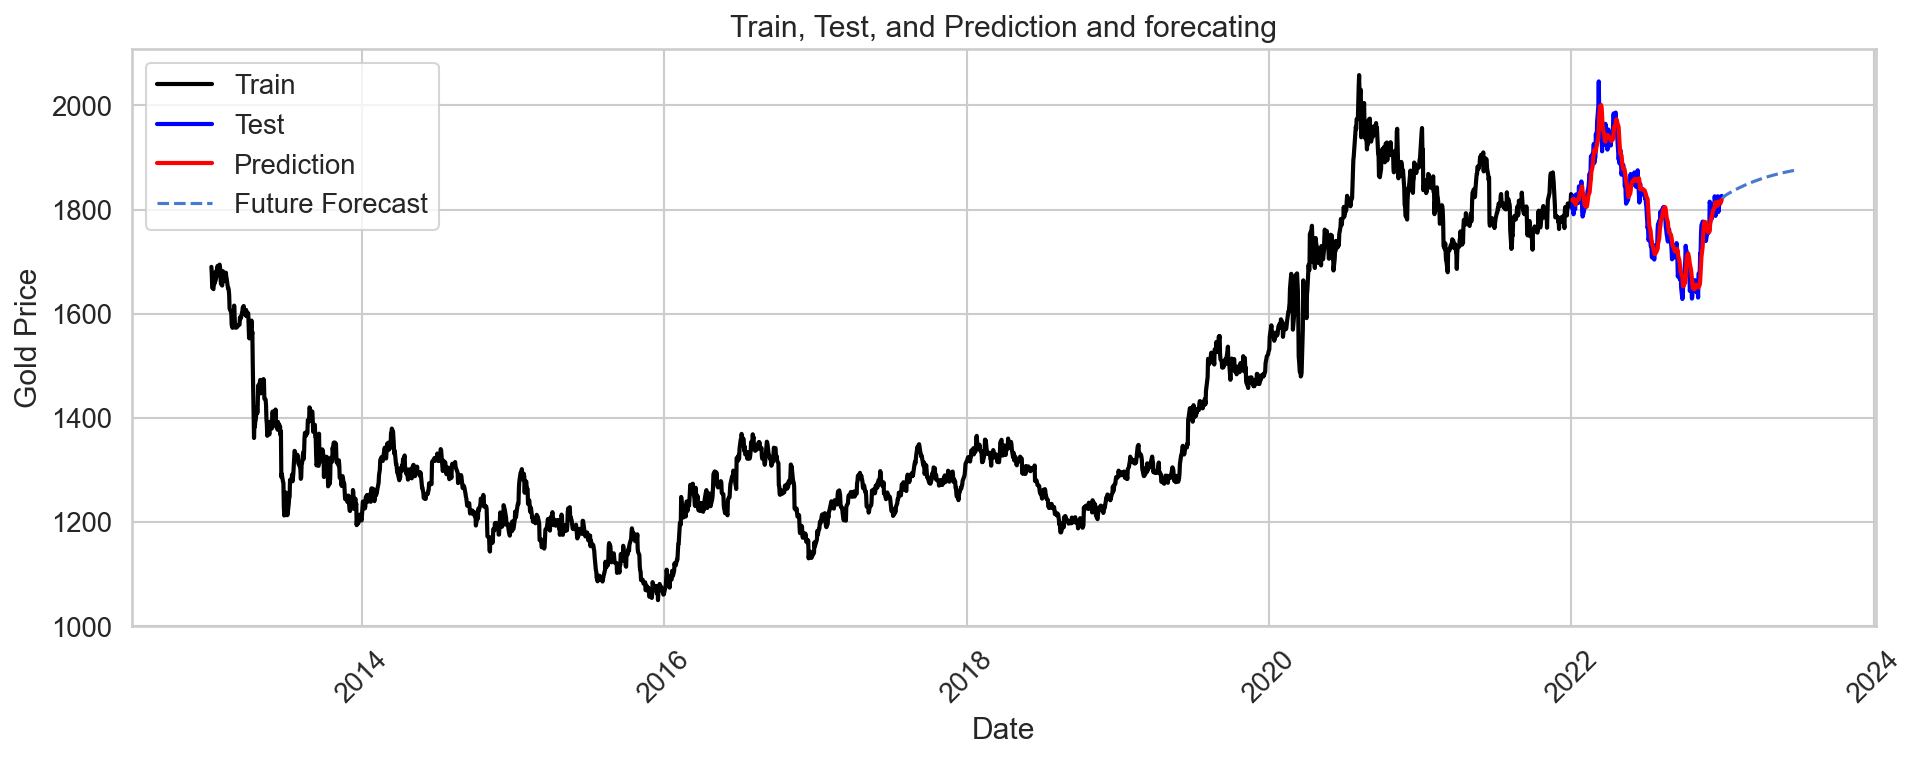

In [59]:
plt.figure(figsize=(15, 5),dpi=150)

plt.plot(gold_df.index[:-test_size], scaler.inverse_transform(train_data), color='black', lw=2,label='Train')
plt.plot(gold_df.index[-test_size:], y_test_true, color='blue', lw=2, label='Test')
plt.plot(gold_df.index[-test_size:], y_test_pred, color='red', lw=2,label='Prediction')
plt.plot(forecast_df.index, forecast_df['predicted_demand'], label='Future Forecast', linestyle='--')

plt.title('Train, Test, and Prediction and forecating')
plt.xlabel('Date')
plt.ylabel('Gold Price')
plt.legend()
plt.xticks(rotation=45) 
plt.show()

### Actual Price for forecated time

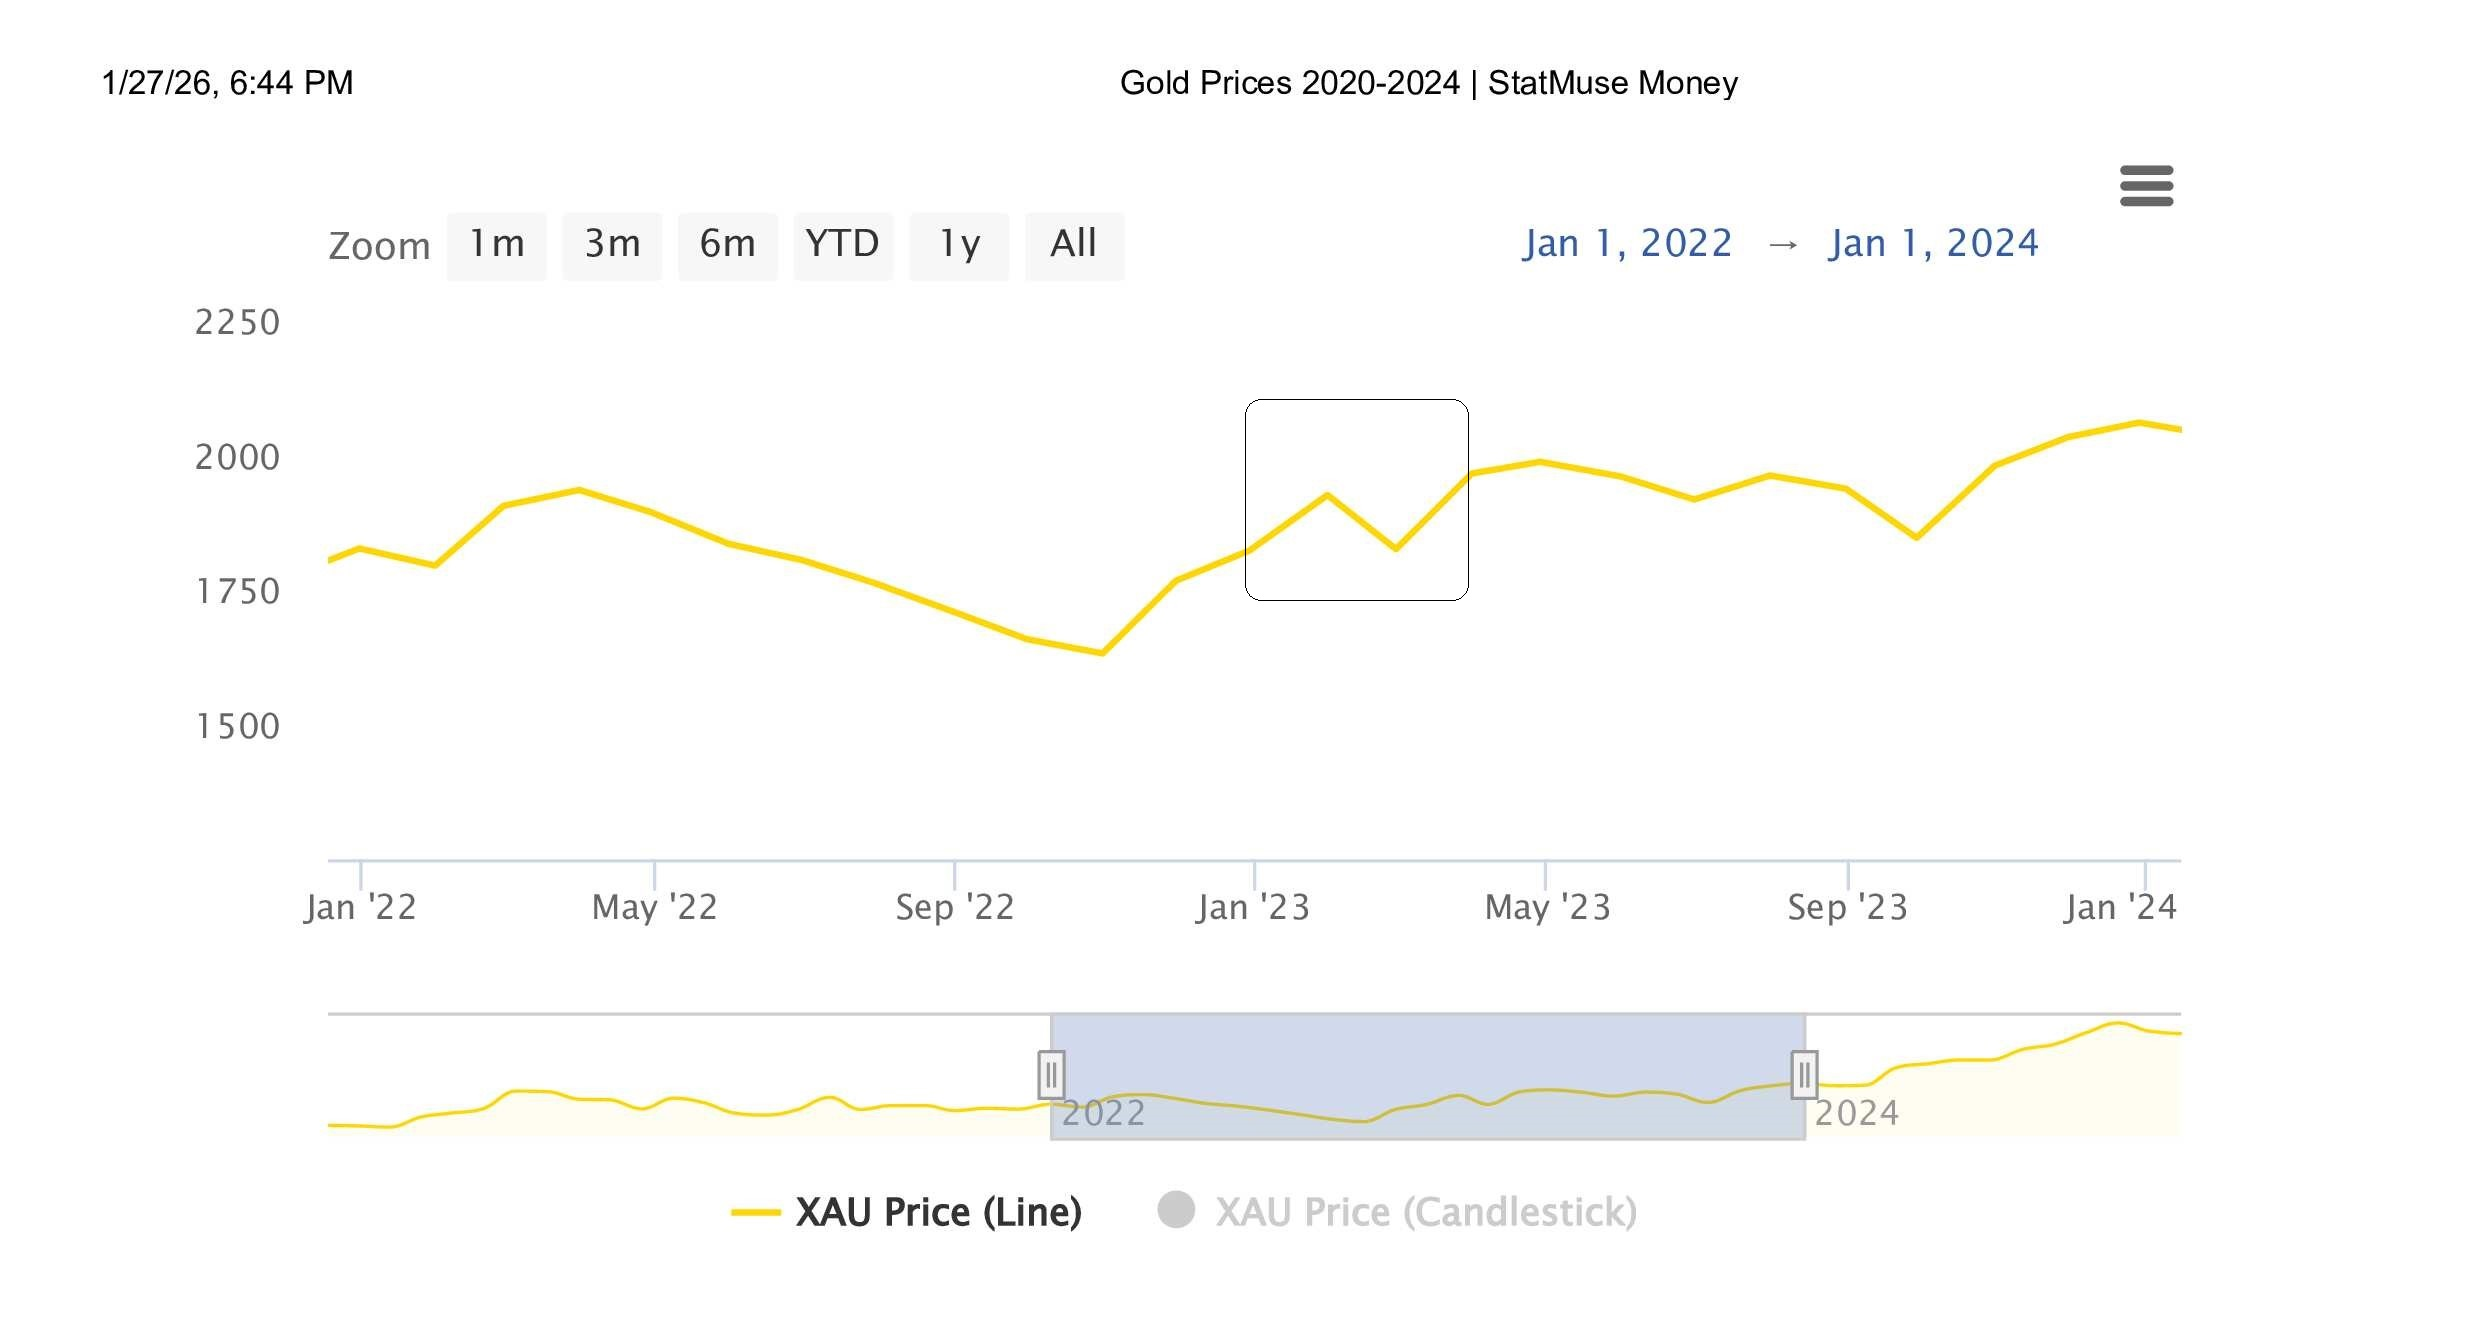

### As can be seen in the project, the model output is almost close to the actual changes in gold in 2023